imtihonga tayorgallik + 4 ta algorithmga data + code

In [1]:
import pandas as pd 
df = pd.read_csv("/Users/sherzodbeksharobiddinov/MLFoundation/Sherzod_dev/2-oy_Model_Building/Data/student_info_liniear.csv") 
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


## Preprocessing datalarni toldirish

In [2]:
def toldir(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == "object":
                df[col].fillna(df[col].mean()[0],inplace = True)
            else:
                df[col].fillna(df[col].mean(),inplace = True)
    return df
df = toldir(df)
df.isnull().sum()


/var/folders/0j/k967ql8509q4hr00sdl88hfh0000gn/T/ipykernel_34404/3755023265.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace = True)


study_hours      0
student_marks    0
dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

# X는 특성 변수 (study_hours), y는 타겟 변수 (student_marks)
x = df[['study_hours']]  # 특성 변수
y = df['student_marks']   # 타겟 변수 (예측할 값)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# 회귀 문제이므로 DecisionTreeRegressor 사용
dt_regressor = DecisionTreeRegressor(random_state=42)


In [5]:
# 모델 학습
dt_regressor.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [6]:
# 예측 수행
y_pred = dt_regressor.predict(x_test)

In [7]:
y_pred

array([75.36 , 77.035, 83.82 , 81.67 , 75.04 , 73.14 , 82.99 , 70.66 ,
       71.005, 75.52 , 80.98 , 84.19 , 71.005, 71.815, 84.71 , 73.14 ,
       72.46 , 82.3  , 76.99 , 70.79 , 84.19 , 75.04 , 82.84 , 80.76 ,
       70.96 , 71.1  , 76.38 , 82.99 , 82.21 , 78.5  , 77.07 , 84.24 ,
       84.19 , 75.36 , 71.005, 79.15 , 84.   , 70.2  , 80.98 , 71.79 ])

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 회귀 모델 평가 지표 계산
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # root_mean_squared_error는 sklearn 1.4+ 버전에서 사용 가능

In [9]:
print('DecisionTreeRegressor 평가 결과:')
print('=' * 40)
print(f'R² Score (결정계수): {r2:.4f}')
print(f'MAE (평균 절대 오차): {mae:.4f}')
print(f'MSE (평균 제곱 오차): {mse:.4f}')
print(f'RMSE (평균 제곱근 오차): {rmse:.4f}')
print('=' * 40)

DecisionTreeRegressor 평가 결과:
R² Score (결정계수): 0.9024
MAE (평균 절대 오차): 1.3091
MSE (평균 제곱 오차): 2.4709
RMSE (평균 제곱근 오차): 1.5719


/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/si

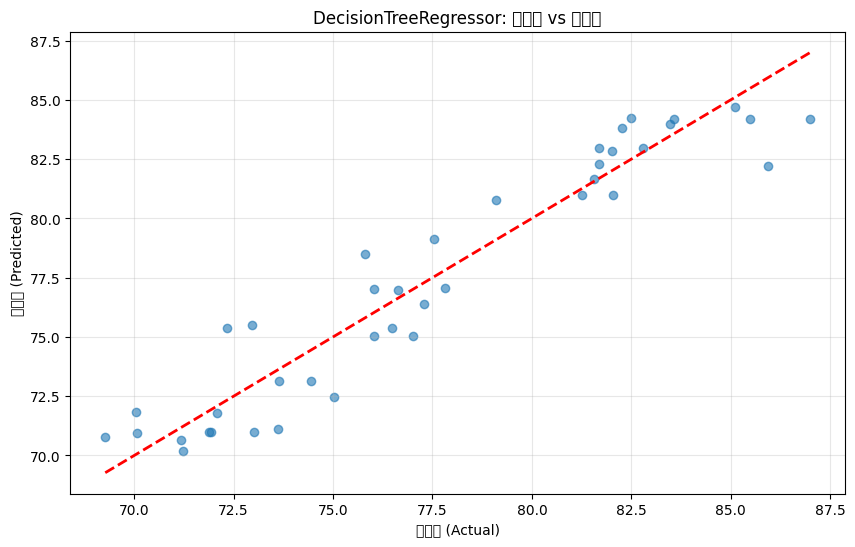

In [10]:
# 실제값 vs 예측값 비교
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제값 (Actual)')
plt.ylabel('예측값 (Predicted)')
plt.title('DecisionTreeRegressor: 실제값 vs 예측값')
plt.grid(True, alpha=0.3)
plt.show()

/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-p

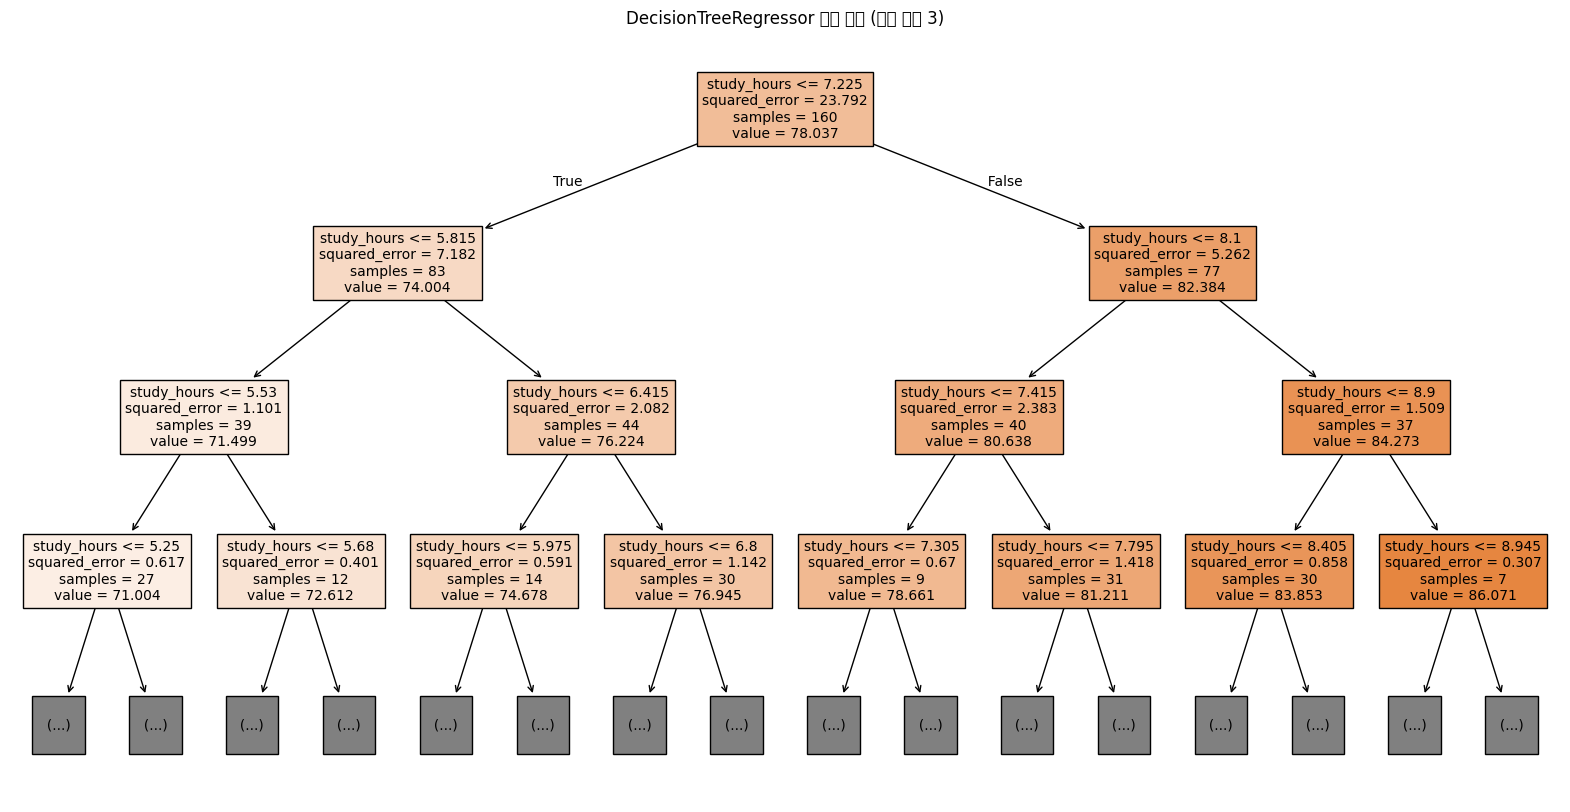

In [11]:
# 트리 구조 시각화
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_regressor, filled=True, feature_names=['study_hours'], 
          fontsize=10, max_depth=3)
plt.title('DecisionTreeRegressor 트리 구조 (최대 깊이 3)')
plt.show()

특성 중요도:
study_hours: 1.0000


/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sherzodbeksharobiddinov/Library/Python/3.9/lib/python/sit

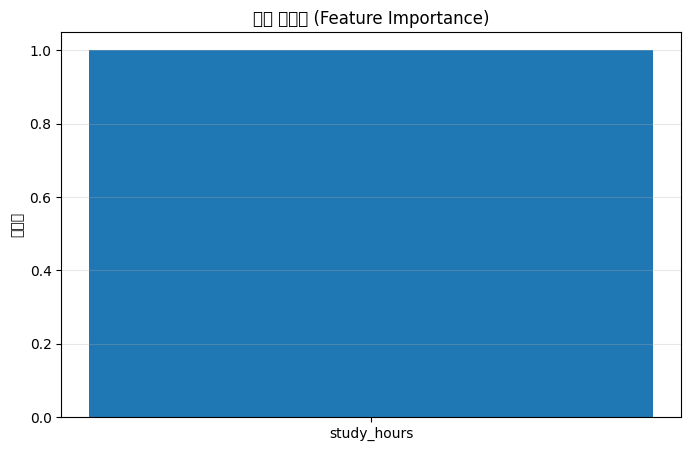

In [12]:
# 특성 중요도 확인
feature_importance = dt_regressor.feature_importances_
print('특성 중요도:')
print(f'study_hours: {feature_importance[0]:.4f}')

plt.figure(figsize=(8, 5))
plt.bar(['study_hours'], feature_importance)
plt.ylabel('중요도')
plt.title('특성 중요도 (Feature Importance)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [13]:
# 예측 결과 샘플 확인
comparison_df = pd.DataFrame({
    '실제값': y_test.values,
    '예측값': y_pred,
    '오차': y_test.values - y_pred
})
print('예측 결과 샘플 (처음 10개):')
print(comparison_df.head(10))

예측 결과 샘플 (처음 10개):
     실제값     예측값     오차
0  76.48  75.360  1.120
1  76.03  77.035 -1.005
2  82.27  83.820 -1.550
3  81.57  81.670 -0.100
4  77.01  75.040  1.970
5  74.44  73.140  1.300
6  82.79  82.990 -0.200
7  71.18  70.660  0.520
8  73.02  71.005  2.015
9  72.96  75.520 -2.560


In [14]:
# 모델 하이퍼파라미터 확인
print('DecisionTreeRegressor 하이퍼파라미터:')
print('=' * 40)
print(f'최대 깊이 (max_depth): {dt_regressor.max_depth}')
print(f'최소 샘플 분할 (min_samples_split): {dt_regressor.min_samples_split}')
print(f'최소 샘플 리프 (min_samples_leaf): {dt_regressor.min_samples_leaf}')
print(f'분할 기준 (criterion): {dt_regressor.criterion}')
print('=' * 40)

DecisionTreeRegressor 하이퍼파라미터:
최대 깊이 (max_depth): None
최소 샘플 분할 (min_samples_split): 2
최소 샘플 리프 (min_samples_leaf): 1
분할 기준 (criterion): squared_error


In [ ]:

from sklearn.tree import DecisionTreeRegressor

max_depths = [3, 5, 10, None]
results = []

for depth in max_depths:
    dt_temp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_temp.fit(x_train, y_train)
    y_pred_temp = dt_temp.predict(x_test)
    r2_temp = r2_score(y_test, y_pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    results.append({
        'max_depth': depth if depth else 'None (무제한)',
        'R²': r2_temp,
        'RMSE': rmse_temp
    })

results_df = pd.DataFrame(results)
print('하이퍼파라미터 튜닝 결과:')
print(results_df)

하이퍼파라미터 튜닝 결과:
    max_depth        R²      RMSE
0           3  0.911369  1.498170
1           5  0.916633  1.452995
2          10  0.902430  1.571906
3  None (무제한)  0.902430  1.571906
